<a href="https://colab.research.google.com/github/JenilMP-09/Titanic_Data_Analysis_With_EDA/blob/main/Task_3_Titanic_Data_Analysis_With_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task Description

* In Task-2, you analyzed the **Titanic Dataset** for survival by gender and class.
* Now, let's perform a **Mini Exploratory Data Analysis (EDA)** on the Titanic dataset with more advanced visualizations.
* You will:
  * Handle missing values better (imputation).
  * Use groupby to find deeper insights.
  * Create multiple visualizations to tell a story.

**What you'll build (Requirements):**
  1. Clean Dataset:
      * Fill missing Age with mean.
      * Drop irrelevant columns (like Cabin).
  2. Analysis Questions:
      * Survival rate by **Age** group.
      * Survival rate by **Embarkation Port**.
      * Survival rate by **Family Size (SibSp + Parch)**.
  3. Visualizations:
      * Age distribution (histogram).
      * Heatmap of correlations.
      * Survival by family size (bar plot).

In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [134]:
# Load the Titanic dataset from Google Drive into a DataFrame:

titanic_df = pd.read_csv("/content/drive/MyDrive/Data_Science_Folder/Datasets/titanic_dataset.csv")

In [135]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [136]:
# Display dataset info: column names, non-null counts, and data types
#
# This helps identify which columns have missing (null) values:

titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


* There are missing values (null values) in "Age", "Fare", and "Cabin" columns.

In [137]:
# Statistical summary of titanic dataset:
#
# Shows count, mean, std, min, percentiles, and max for each numeric column

titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


1. Clean Dataset:

    * Fill missing Age with mean:

In [138]:
# Fill missing values in the 'Age' column with the median age
#
# Using median instead of mean makes the imputation more robust to outliers:

titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].median())

In [139]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          418 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [140]:
# Fill missing values in the 'Fare' column with the median fare
#
# Using median to avoid skew from extreme fare values:

titanic_df["Fare"] = titanic_df["Fare"].fillna(titanic_df["Fare"].median())

    * Drop irrelevant columns (like Cabin):

In [141]:
# Drop the 'Cabin' column entirely because it has too many missing values
#
# (only ~22% non-null), making it unreliable for analysis

titanic_df.drop(columns=["Cabin"], inplace=True)
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          418 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         418 non-null    float64
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 36.1+ KB


2. Analysis Questions:

    * Survival rate by "Age" group:

In [142]:
# Define age bins and labels to categorize passengers into meaningful age groups:

bins = [0, 12, 18, 30, 45, 60, 80]
labels = ["Child (0-12)", "Teen (13-18)", "Young Adult (19-30)", "Adult (31-45)", "Middle-aged (46-60)", "Senior (61-80)"]

# Create a new 'Age_Group' column by binning the 'Age' column using the defined bins
#
# pd.cut assigns each passenger to the appropriate age group label

titanic_df["Age_Group"] = pd.cut(titanic_df["Age"], bins=bins, labels=labels)

In [143]:
# Calculate survival rate (%) per age group
#
# observed=True ensures only age groups that appear in the data are shown:

round(titanic_df.groupby("Age_Group", observed=True)["Survived"].mean()*100, 2)

,Survived
Age_Group,
Child (0-12),48.00
Teen (13-18),41.38
Young Adult (19-30),33.62
Adult (31-45),35.00
Middle-aged (46-60),43.90
Senior (61-80),36.36


    * Survival rate by "Embarkation Port":

In [144]:
# Calculates survival rate (%) by embarkation port:

round(titanic_df.groupby("Embarked")["Survived"].mean() * 100, 2)

,Survived
Embarked,
C,39.22
Q,52.17
S,32.59


    * Survival rate by "Family size (SibSp + Parch)":

In [145]:
# Calculate family size onboard by adding "SibSp" and "Parch" column's data:

titanic_df["FamilySize"] = titanic_df["SibSp"] + titanic_df["Parch"]

In [146]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_Group,FamilySize
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q,Adult (31-45),0
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S,Middle-aged (46-60),1
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q,Senior (61-80),0
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S,Young Adult (19-30),0
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S,Young Adult (19-30),2


In [147]:
# Calculates survival rate (%) by family size:

round(titanic_df.groupby("FamilySize")["Survived"].mean() * 100, 2)

,Survived
FamilySize,
0,26.88
1,48.65
2,52.63
3,71.43
4,28.57
5,66.67
6,25.00
7,50.00
10,50.00


3. Visualizations:

    * Age distribution (histogram):

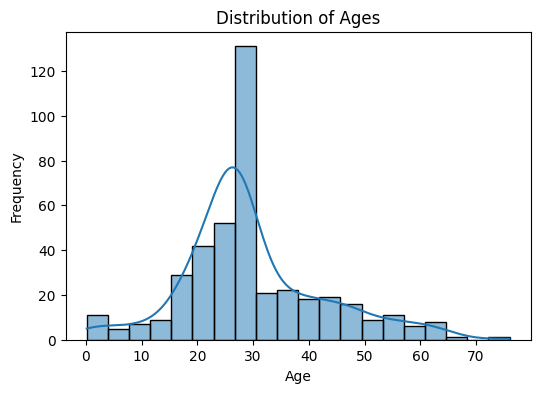

In [148]:
# A histogram showing the distribution of ages:

plt.figure(figsize=(6, 4))
sns.histplot(titanic_df["Age"], bins=20, kde=True)
plt.title("Distribution of Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

    * Heatmap of correlations:

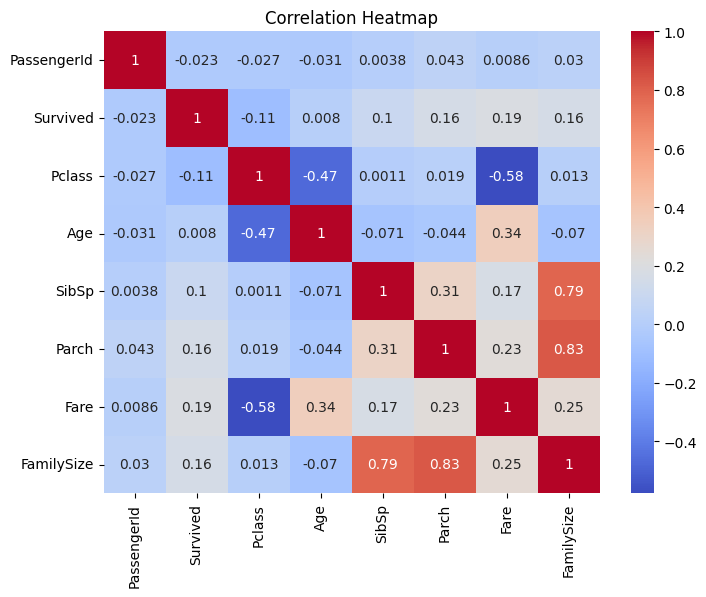

In [149]:
# A heatmap showing the correlations of all numerical data:

plt.figure(figsize=(8, 6))
sns.heatmap(titanic_df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

    * Survival rate by family size (bar plot):

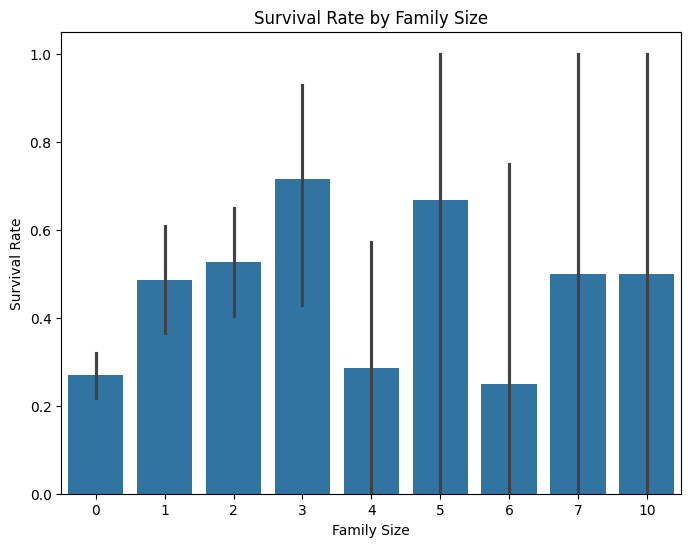

In [150]:
# Bar chart showing survival rate by family size:

plt.figure(figsize=(8, 6))
sns.barplot(x="FamilySize", y="Survived", data=titanic_df)
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.show()